# Preparing The Keyword Spotting Dataset

## Imports:

In [1]:
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile
from tqdm import tqdm
import os
import random
import shutil
from IPython.display import Audio, display
from ipywidgets import widgets
import librosa
import librosa.display
import soundfile as sf
import multiprocessing
from functools import partial

## Load the Dataset:

I am going to use Google Speech Commands Dataset for this project since it is simpler and made for the Keyword Spotting task. It is a straight forward dataset with a few activation words in English.

- Link: https://www.tensorflow.org/datasets/catalog/speech_commands?hl=pt-br

**Other Options with more complex work needed were**:

- Fluent Speech Commands Dataset: https://fluent.ai/fluent-speech-commands-a-dataset-for-spoken-language-understanding-research/

- Mozilla Common Voice: https://commonvoice.mozilla.org/en/datasets

In [2]:
(ds_train, ds_validation, ds_test), ds_info = tfds.load('speech_commands', split=['train', 'validation', 'test'], shuffle_files=True, with_info=True, as_supervised=True,)

2025-09-24 13:34:32.541572: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-24 13:34:32.549848: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758731672.559231   27921 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758731672.562211   27921 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758731672.569995   27921 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
label_names = ds_info.features['label'].names
sample_rate = ds_info.features['audio'].sample_rate

In [4]:
ds_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.int16, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

#### Criando um Dataset Local e Selecionando os Labels Desejados:

In [5]:
if os.path.isdir('../dataset'):
    shutil.rmtree("../dataset")


base_dir = '../dataset'

splits = {
    'train': ds_train,
    'validation': ds_validation,
    'test': ds_test,
}

for split_name, ds in splits.items():
    split_dir = os.path.join(base_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)
    
    for label_name in label_names:
        label_dir = os.path.join(split_dir, label_name)
        os.makedirs(label_dir, exist_ok=True)
        
    counters = {label: 0 for label in label_names}

    for audio_tensor, label_tensor in tqdm(ds, desc=f"Salvando {split_name}"):
        audio_np = audio_tensor.numpy()
        label_int = label_tensor.numpy()
        label_str = label_names[label_int]
        count = counters[label_str]
        filename = f"{label_str}_{count}.wav"
        output_path = os.path.join(split_dir, label_str, filename)
        scipy.io.wavfile.write(output_path, sample_rate, audio_np)
        counters[label_str] += 1

paths = ['../dataset/train', '../dataset/validation', '../dataset/test']

for path in paths:
    for folder in os.listdir(path):
        if(folder == "down" or folder == "left" or folder == "up" or folder == "right" or folder == "up" or folder == "yes"):
            for file in os.listdir(os.path.join(path, folder)):
                src_path = os.path.join(path, folder, file)
                dst_dir = os.path.join(path, '_unknown_')
                os.makedirs(dst_dir, exist_ok=True)
                dst_path = os.path.join(dst_dir, file)
                os.rename(src_path, dst_path)
            os.rmdir(os.path.join(path, folder))

Salvando test: 100%|██████████| 4890/4890 [00:00<00:00, 5870.44it/s]


## Exploring the Dataset:

#### Verifying the Dataset:

In [6]:
base_dir = '../dataset'
splits = ['train', 'validation', 'test']

result_labels = []
result_counts = []

for split in splits:
    split_path = os.path.join(base_dir, split)

    class_counts = {}

    class_dirs = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]

    for class_name in class_dirs:
        class_path = os.path.join(split_path, class_name)
        num_files = len([f for f in os.listdir(class_path) if f.endswith('.wav')])
        class_counts[class_name] = num_files
        
    sorted_classes = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)

    labels = [item[0] for item in sorted_classes]
    counts = [item[1] for item in sorted_classes]

    result_labels.append(labels)
    result_counts.append(counts)



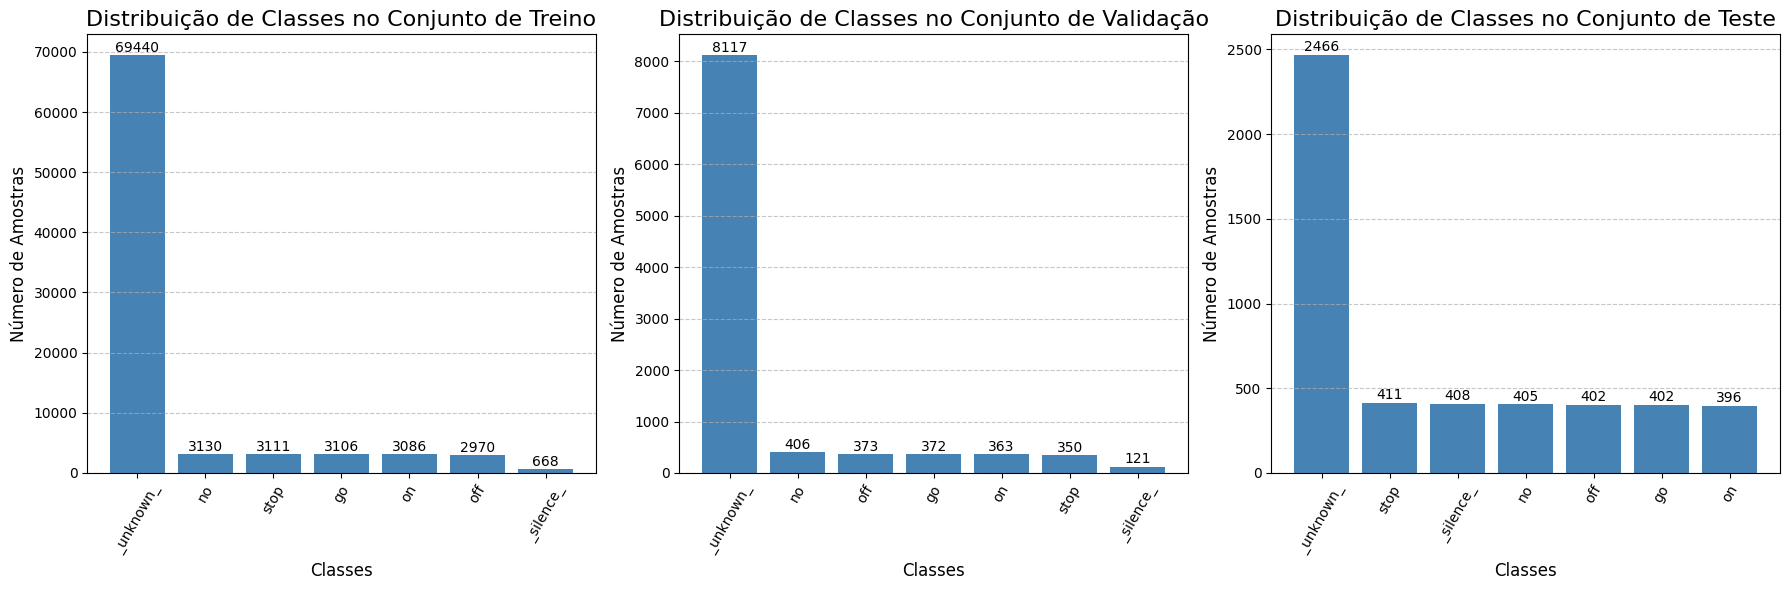

In [7]:
titles = ['Treino', 'Validação', 'Teste']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ax in enumerate(axes):

    bars = ax.bar(result_labels[i], result_counts[i], color='steelblue')

    ax.set_title(f'Distribuição de Classes no Conjunto de {titles[i]}', fontsize=16)
    ax.set_ylabel('Número de Amostras', fontsize=12)
    ax.set_xlabel('Classes', fontsize=12)
    ax.tick_params(axis='x', rotation=60)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

## Data Augmentation:

In [8]:
# def calcular_rms(sinal):
#     return np.sqrt(np.mean(sinal**2))

# def adicionar_ruido_com_snr(sinal, snr_db, ruido):
#     rms_sinal = calcular_rms(sinal)
#     if rms_sinal == 0: return sinal
#     if len(ruido) < len(sinal):
#         ruido = np.tile(ruido, int(np.ceil(len(sinal) / len(ruido))))
#     ruido = ruido[:len(sinal)]
#     rms_ruido_atual = calcular_rms(ruido)
#     if rms_ruido_atual == 0: return sinal
#     rms_ruido_desejado = rms_sinal / (10**(snr_db / 20))
#     ruido_escalado = ruido * (rms_ruido_desejado / rms_ruido_atual)
    
#     return sinal + ruido_escalado

# def aplicar_pitch_shift(sinal, sr, n_steps):
#     return librosa.effects.pitch_shift(y=sinal, sr=sr, n_steps=n_steps)

# def aplicar_time_stretch(sinal, rate):
#     return librosa.effects.time_stretch(y=sinal, rate=rate)

# def normalizar_audio(sinal):
#     pico = np.max(np.abs(sinal))
#     if pico > 1.0:
#         return sinal / pico
#     return sinal


In [9]:
# DATASET_ORIGINAL_PATH = '../dataset'
# RUIDOS_PATH = '../ruidos'
# OUTPUT_PATH = '../dataset_augmented'

# TARGET_CLASSES = ['no', 'stop', 'go', 'on', 'off']
# SETS_TO_AUGMENT = ['train', 'validation']
# AUGMENTATION_FACTOR = 24 # 1 original + 23 aumentados

# TARGET_SR = 16000

In [10]:
# def processar_arquivo(caminho_arquivo_original, ruidos_de_fundo):
#     try:
#         pasta_classe_path = os.path.dirname(caminho_arquivo_original)
#         nome_arquivo = os.path.basename(caminho_arquivo_original)
#         sinal_original, sr = librosa.load(caminho_arquivo_original, sr=TARGET_SR)

#         for i in range(AUGMENTATION_FACTOR - 1):
#             sinal_aumentado = None
#             aug_type_name = ""
            
#             if i < 8:
#                 aug_type_name = f"bgnoise_{i}"
#                 ruido_selecionado = random.choice(ruidos_de_fundo)
#                 snr_db = random.uniform(15, 25)
#                 sinal_aumentado = adicionar_ruido_com_snr(sinal_original, snr_db, ruido_selecionado)
#             elif i < 16:
#                 aug_type_name = f"whitenoise_{i-8}"
#                 ruido_branco = np.random.randn(len(sinal_original))
#                 snr_db = random.uniform(15, 30)
#                 sinal_aumentado = adicionar_ruido_com_snr(sinal_original, snr_db, ruido_branco)
#             elif i < 20:
#                 aug_type_name = f"pitch_{i-16}"
#                 n_steps = random.uniform(-2.0, 2.0)
#                 sinal_aumentado = aplicar_pitch_shift(sinal_original, sr, n_steps)
#             else:
#                 aug_type_name = f"stretch_{i-20}"
#                 rate = random.uniform(0.9, 1.1)
#                 sinal_aumentado = aplicar_time_stretch(sinal_original, rate)
#                 sinal_aumentado = librosa.util.fix_length(data=sinal_aumentado, size=len(sinal_original))

#             if sinal_aumentado is not None:
#                 sinal_aumentado = normalizar_audio(sinal_aumentado)
#                 nome_base, extensao = os.path.splitext(nome_arquivo)
#                 novo_nome_arquivo = f"{nome_base}_aug_{aug_type_name}{extensao}"
#                 caminho_saida = os.path.join(pasta_classe_path, novo_nome_arquivo)
#                 sf.write(caminho_saida, sinal_aumentado, sr)
#         return None # Retorna sucesso
#     except Exception as e:
#         return f"Erro processando {caminho_arquivo_original}: {e}"

In [11]:
# print("--- INICIANDO SCRIPT DE DATA AUGMENTATION (MULTIPROCESSADO) ---")

# if os.path.exists(OUTPUT_PATH):
#     print(f"Removendo pasta de saída antiga: {OUTPUT_PATH}")
#     shutil.rmtree(OUTPUT_PATH)

# print(f"Copiando estrutura original de '{DATASET_ORIGINAL_PATH}' para '{OUTPUT_PATH}'...")
# shutil.copytree(DATASET_ORIGINAL_PATH, OUTPUT_PATH)

# print(f"\nUsando a taxa de amostragem definida: {TARGET_SR} Hz")

# print("Carregando arquivos de ruído...")
# ruidos_de_fundo = []
# for arquivo_ruido in os.listdir(RUIDOS_PATH):
#     if arquivo_ruido.lower().endswith('.mp3'):
#         caminho_completo = os.path.join(RUIDOS_PATH, arquivo_ruido)
#         ruido, _ = librosa.load(caminho_completo, sr=TARGET_SR)
#         ruidos_de_fundo.append(ruido)
#         print(f" - '{arquivo_ruido}' carregado.")

# lista_de_tarefas = []
# for subset in SETS_TO_AUGMENT:
#     for classe in TARGET_CLASSES:
#         pasta_classe_path = os.path.join(OUTPUT_PATH, subset, classe)
#         arquivos_originais = [os.path.join(pasta_classe_path, f) for f in os.listdir(pasta_classe_path) if f.endswith('.wav')]
#         lista_de_tarefas.extend(arquivos_originais)

# print(f"\nTotal de {len(lista_de_tarefas)} arquivos a serem aumentados.")

# num_processos = multiprocessing.cpu_count() - 3
# print(f"Iniciando pool com {num_processos} processos...")

# func_parcial = partial(processar_arquivo, ruidos_de_fundo=ruidos_de_fundo)

# with multiprocessing.Pool(processes=num_processos) as pool:
#     resultados = list(tqdm(pool.imap(func_parcial, lista_de_tarefas), total=len(lista_de_tarefas)))

# print("\n--- PROCESSO DE AUGMENTATION CONCLUÍDO! ---")
# print(f"Dataset aumentado salvo em: {OUTPUT_PATH}")

In [12]:
# DATASET_PATH = '../dataset_augmented'
# TARGET_CLASS = '_silence_'
# TARGET_SR = 16000
# AUDIO_LENGTH_SAMPLES = 16000

# AUGMENTATION_FACTORS = {
#     'train': 100,
#     'validation': 80
# }

# def gerar_um_arquivo_de_ruido(output_path):
#     """Gera e salva um único arquivo de ruído branco no caminho especificado."""
#     try:
#         amplitude = 0.005
#         noise_signal = (np.random.randn(AUDIO_LENGTH_SAMPLES) * amplitude).astype(np.float32)
#         sf.write(output_path, noise_signal, TARGET_SR)
#         return None
#     except Exception as e:
#         return f"Erro ao criar {output_path}: {e}"

In [13]:
# print("--- INICIANDO AUGMENTATION OTIMIZADA PARA '_silence_' ---")

# lista_de_tarefas_paths = []
# for subset, factor in AUGMENTATION_FACTORS.items():
#     silence_dir = os.path.join(DATASET_PATH, subset, TARGET_CLASS)
#     if not os.path.isdir(silence_dir):
#         continue

#     original_files = [f for f in os.listdir(silence_dir) if f.endswith('.wav') and '_aug_' not in f]
#     if not original_files:
#         continue
        
#     num_original_files = len(original_files)
#     num_total_arquivos_novos = num_original_files * (factor - 1)
    
#     print(f"\nConjunto '{subset}': {num_original_files} arquivos originais. Gerando {num_total_arquivos_novos} novos arquivos de ruído.")

#     # Cria a lista de todos os caminhos de saída que precisamos gerar
#     for i in range(num_total_arquivos_novos):
#         # O nome do arquivo não precisa mais se basear em um original
#         new_filename = f"generated_silence_whitenoise_{i}.wav"
#         output_path = os.path.join(silence_dir, new_filename)
#         lista_de_tarefas_paths.append(output_path)
        

# print(f"\nTotal de {len(lista_de_tarefas_paths)} arquivos de ruído a serem gerados em paralelo.")
# num_processos = multiprocessing.cpu_count() - 1
# print(f"Iniciando pool com {num_processos} processos...")

# with multiprocessing.Pool(processes=num_processos) as pool:
#     list(tqdm(pool.imap_unordered(gerar_um_arquivo_de_ruido, lista_de_tarefas_paths), total=len(lista_de_tarefas_paths)))

# print("\n--- Augmentation da classe '_silence_' concluída! ---")

In [14]:
base_dir = '../dataset_augmented'
splits = ['train', 'validation', 'test']

result_labels = []
result_counts = []

for split in splits:
    split_path = os.path.join(base_dir, split)

    class_counts = {}

    class_dirs = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]

    for class_name in class_dirs:
        class_path = os.path.join(split_path, class_name)
        num_files = len([f for f in os.listdir(class_path) if f.endswith('.wav')])
        class_counts[class_name] = num_files
        
    sorted_classes = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)

    labels = [item[0] for item in sorted_classes]
    counts = [item[1] for item in sorted_classes]

    result_labels.append(labels)
    result_counts.append(counts)



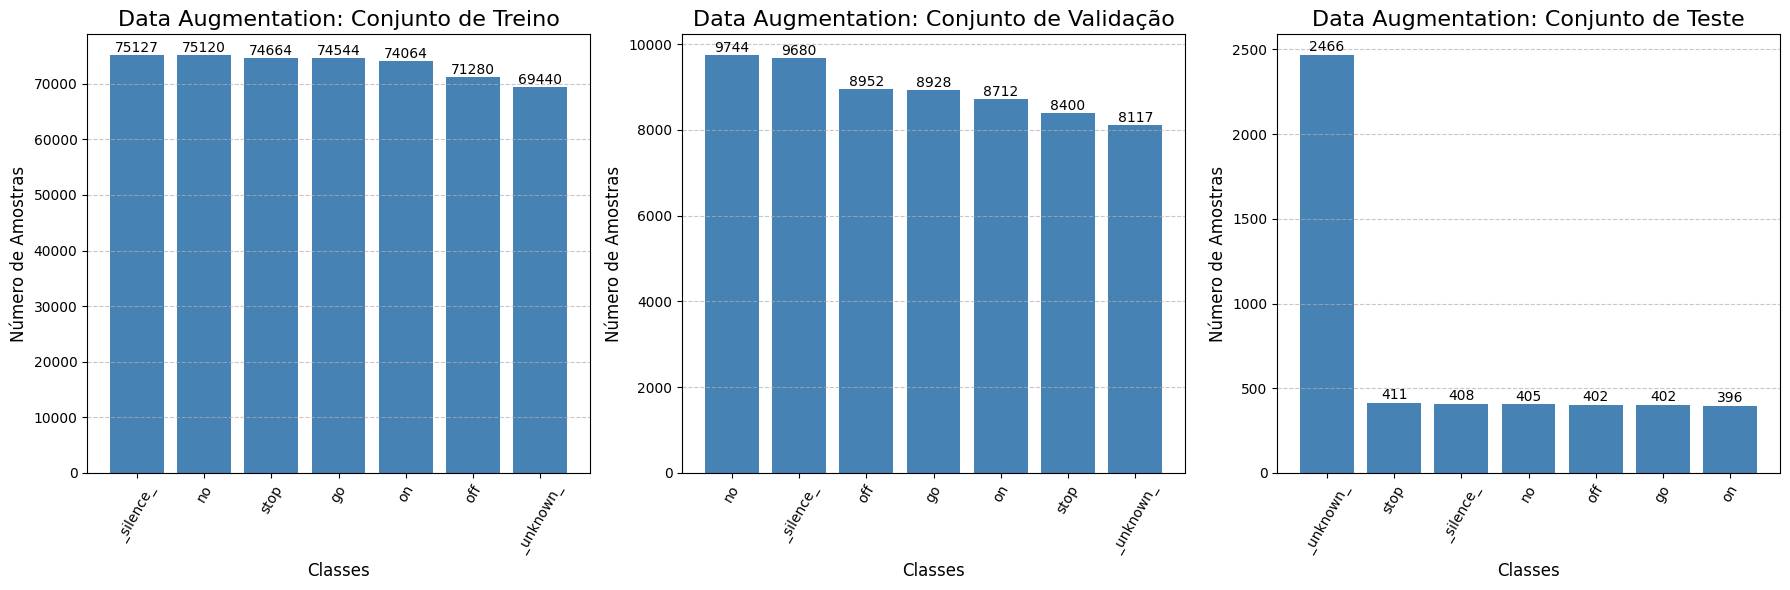

In [15]:
titles = ['Treino', 'Validação', 'Teste']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ax in enumerate(axes):
    bars = ax.bar(result_labels[i], result_counts[i], color='steelblue')

    ax.set_title(f'Data Augmentation: Conjunto de {titles[i]}', fontsize=16)
    ax.set_ylabel('Número de Amostras', fontsize=12)
    ax.set_xlabel('Classes', fontsize=12)
    ax.tick_params(axis='x', rotation=60)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

## Data Removal:

In [16]:
def del_samples(path, quant):
    all_files = os.listdir(path)
    for _ in tqdm(range(0, quant), desc=f"Deletando de {path}"):
        del_arq = random.choice(all_files)
        all_files.remove(del_arq)
        os.remove(os.path.join(path, del_arq))

In [17]:
del_samples("../dataset/train/_unknown_", 66310)

del_samples("../dataset/validation/_unknown_", 7711)

del_samples("../dataset/test/_unknown_", 2000)

Deletando de ../dataset/test/_unknown_: 100%|██████████| 2000/2000 [00:00<00:00, 40592.13it/s]


In [18]:
base_dir = '../dataset'
splits = ['train', 'validation', 'test']

result_labels = []
result_counts = []

for split in splits:
    split_path = os.path.join(base_dir, split)

    class_counts = {}

    class_dirs = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]

    for class_name in class_dirs:
        class_path = os.path.join(split_path, class_name)
        num_files = len([f for f in os.listdir(class_path) if f.endswith('.wav')])
        class_counts[class_name] = num_files
        
    sorted_classes = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)

    labels = [item[0] for item in sorted_classes]
    counts = [item[1] for item in sorted_classes]

    result_labels.append(labels)
    result_counts.append(counts)



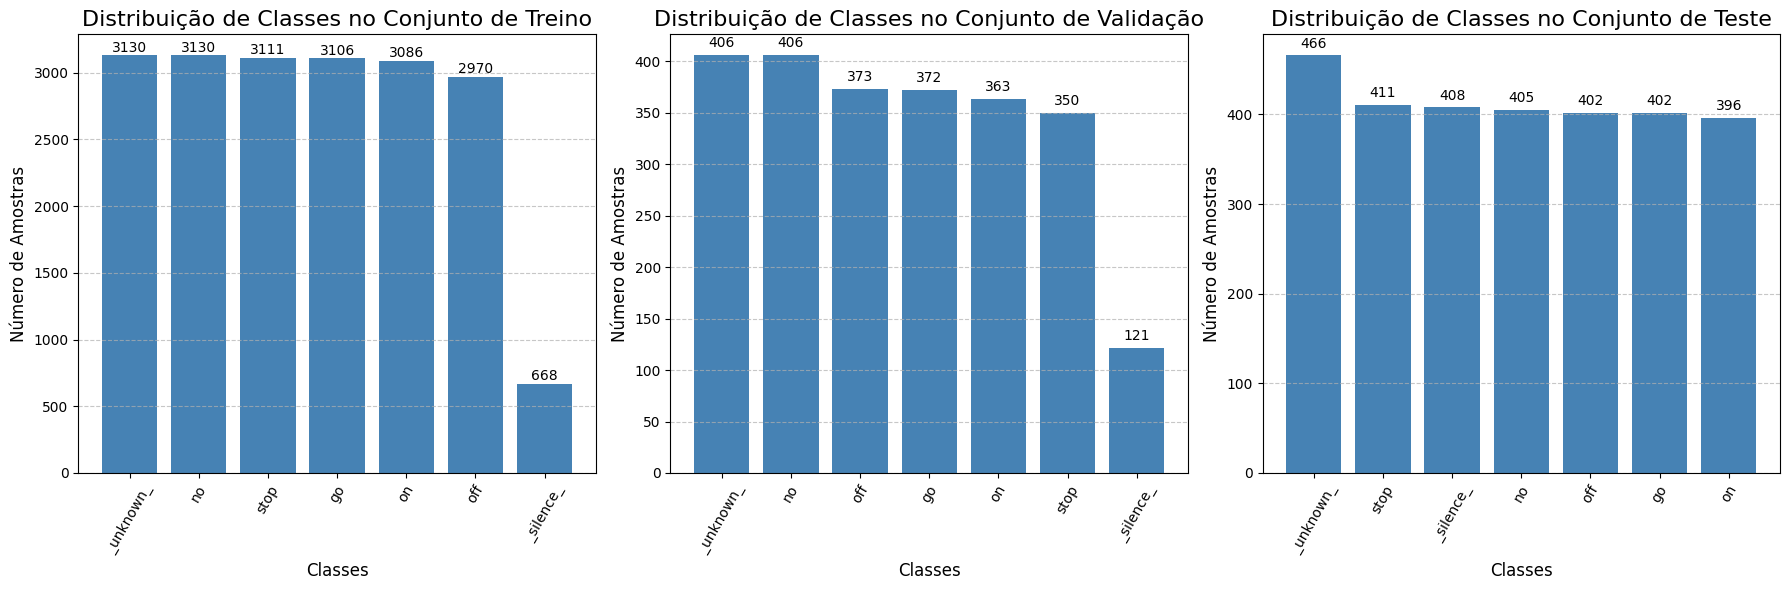

In [19]:
titles = ['Treino', 'Validação', 'Teste']

# Cria a figura e os subplots. `figsize` foi ajustado para melhor visualização.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Itera sobre os conjuntos de dados para criar cada subplot
for i, ax in enumerate(axes):
    # Plota as barras
    bars = ax.bar(result_labels[i], result_counts[i], color='steelblue')

    # Define o título de cada subplot
    ax.set_title(f'Distribuição de Classes no Conjunto de {titles[i]}', fontsize=16)
    ax.set_ylabel('Número de Amostras', fontsize=12)
    ax.set_xlabel('Classes', fontsize=12)

    # Rotaciona os labels do eixo x para melhor visualização
    ax.tick_params(axis='x', rotation=60)
    
    # Adiciona o grid no eixo y
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Adiciona os valores no topo de cada barra
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), va='bottom', ha='center')

# Ajusta o layout para evitar sobreposição de títulos e labels
plt.tight_layout()
plt.show()

## Visualizing Samples:

In [20]:
def plotar_exemplos_integrado(base_path: str, exemplos_por_classe: int = 5):
    try:
        classes = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    except FileNotFoundError:
        print(f"Erro: O diretório '{base_path}' não foi encontrado.")
        return

    # Lista principal que vai conter as linhas (HBox) de cada classe
    linhas_de_widgets = []

    for class_name in classes:
        class_path = os.path.join(base_path, class_name)
        
        try:
            wav_files = [f for f in os.listdir(class_path) if f.lower().endswith('.wav')]
            if not wav_files:
                continue

            num_a_selecionar = min(exemplos_por_classe, len(wav_files))
            arquivos_selecionados = random.sample(wav_files, num_a_selecionar)

            # Lista para os "cards" (widgets.Output) desta classe
            blocos_para_linha_atual = []
            
            # Adiciona um rótulo no início da linha para identificar a classe
            label_classe = widgets.Label(
                value=f"{class_name}:",
                layout=widgets.Layout(display='flex', align_items='center', width='80px') # Layout para alinhar verticalmente
            )
            blocos_para_linha_atual.append(label_classe)

            for file_name in arquivos_selecionados:
                file_path = os.path.join(class_path, file_name)
                
                # Cria o widget de "card" individual
                card = widgets.Output(layout={'border': '1px solid black', 'padding': '5px', 'width': '180px'})
                
                with card:
                    try:
                        # Carrega o áudio
                        sr, audio = scipy.io.wavfile.read(file_path)
                        if audio.ndim > 1:
                            audio = audio[:, 0]

                        # --- Geração do Gráfico em Memória ---
                        # Cria uma figura pequena, específica para este card
                        fig, ax = plt.subplots(figsize=(3, 2), dpi=75)
                        ax.plot(audio, color='dodgerblue')
                        ax.axis('off') # Remove eixos para um visual limpo
                        plt.tight_layout()
                        
                        # Exibe a figura e a fecha para não poluir a memória
                        plt.show(fig)
                        plt.close(fig)

                        # Exibe o player de áudio
                        display(Audio(data=audio, rate=sr))
                    
                    except Exception as e:
                        print(f"Erro: {e}")

                blocos_para_linha_atual.append(card)

            # Agrupa todos os cards da classe em uma linha horizontal
            linha = widgets.HBox(blocos_para_linha_atual)
            linhas_de_widgets.append(linha)
        
        except FileNotFoundError:
            continue

    # Exibe todas as linhas empilhadas verticalmente
    display(widgets.VBox(linhas_de_widgets))

In [21]:
plotar_exemplos_integrado("../dataset/train")